# Purpose of Script

Perform exploratory analysis of electronic health records investigating relationships between cardiac events and flu cases.


### Pre-existing literature:

1. Effect of Influenza Vaccination on Major Cardiovascular Events and Mortality: A Systematic Review and Meta-Analysis of Randomized Controlled Trials ([September 2026](https://pubmed.ncbi.nlm.nih.gov/42720234/$0))
    * "Influenza vaccination significantly reduced major adverse cardiovascular events and cardiovascular mortality. A borderline reduction was observed for myocardial infarction and all-cause mortality. No significant differences were found for stroke, coronary revascularization, or heart failure-related hospitalization."


2. Influenza vaccination associates with reduced risk of incident ischemic stroke among older adults with diabetes: A population-based retrospective cohort study ([July 2026](https://pmc.ncbi.nlm.nih.gov/articles/PMC13432903/$0)).
    * "Seasonal influenza vaccination was associated with a significantly reduced risk of incident IS within 7 months among older adults with diabetes"

### Things to look out for:

* Duplicates (1-2% of EHR data are historically duplicate information)
* Repeated entries with varying granularity of condition or treatment (parent - child - sibling)

## Data Selection

The dataset was chosen based on the size of the data, and the accessibility through Google BigQuery. The data was initially suggested in the email provided by Justin, with example indications. 

## Methodology
abc


In [129]:
## import statements
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

plt.style.use("ggplot")

from google.cloud import bigquery
from IPython.display import Image, Markdown

CLIENT = bigquery.Client(project="project-d60bc1f8-9487-4a43-958")

# https://docs.cloud.google.com/bigquery/docs/python-libraries?hl=en&utm_source=chatgpt.com#google-cloud-bigquery

### Define External Concept Codes

The National Cancer Institute provides a very intuitive search engine to find concept identifiers for vocabularies such as SNOMED.

SNOMED codes were obtained using this [search engine](https://evsexplore.semantics.cancer.gov/).

To assess the relationship between influenza and cardiac events, the following 'general' concepts were used:
* Influenza
* Myocardial Infarction (Heart attack)
* Cerebroaccidents (Strokes)
* Influenza vaccination

** ICD10 doesn't look like 'standard concepts' for influenza

### Example of Concept and Descendents in SNOMED Vocabulary

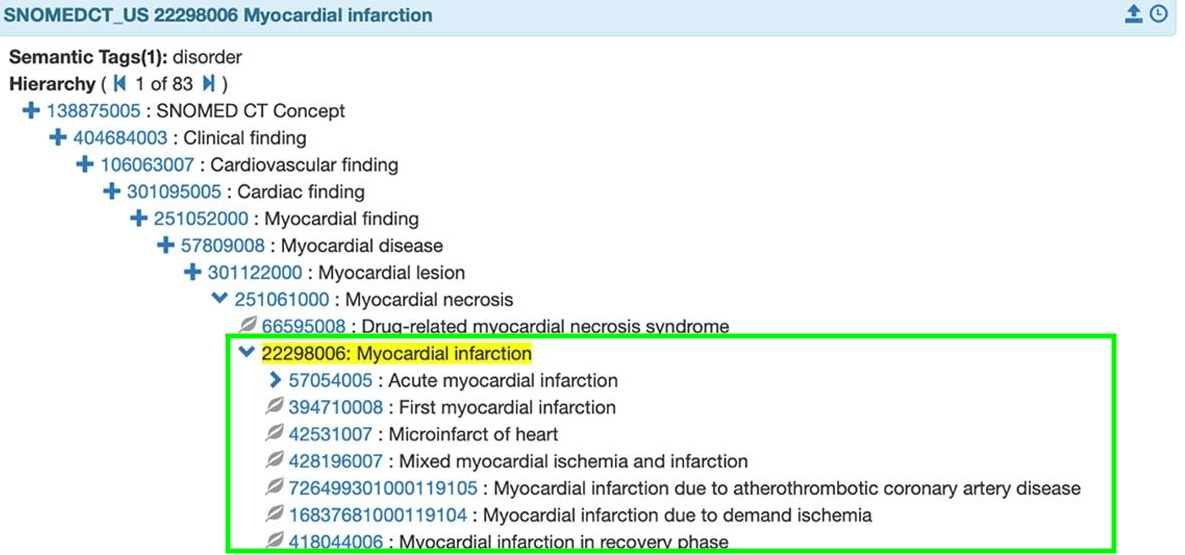

In [130]:
# from IPython.display import Image

display(Markdown("### Example of Concept and Descendents in SNOMED Vocabulary"))
Image(filename='images/snomed_example.jpg') 

In [131]:
## define codes manually
cardiac_concept_codes = {
    'cerebro_accident': '230690007',
    'myocardial_infarction': '22298006'
                        }

flu_concept_codes = {
    'general_flu' : "6142004",
    'flu_virus' : "725894000",
    'flu_b' :  "24662006",
    'flu_a' :"442438000",
    'seasonal_flu' : "719590007",
    'pandemic_flu' : "719865001",
    'flu_c' : "81524006"
                    }

vaccine_concept_codes = {
    'flu_vaccine_1': "C178427",
    'flu_vaccine_2': '86198006'
                         }

In [134]:
def cleanup_empty_columns(df: pd.DataFrame, column_list: list = []) -> pd.DataFrame:
  """

  """

  cols_to_drop = [
                'condition_start_datetime', 'condition_end_datetime', 'stop_reason',
                'visit_detail_id', 'condition_status_source_value', 'condition_status_concept_id',
                'provider_id_1', 'care_site_id', 'gender_source_concept_id',
                'ethnicity_source_concept_id', 'gender_concept_id', 'ethnicity_concept_id',
                "race_source_concept_id", "birth_datetime", 'gender_source_value',
                'race_source_value', 'ethnicity_source_value', 'person_source_value'
                  ]



  for col in cols_to_drop:
    # print(f'looking at col: {col}')
    if col in df.columns:
      # print(f'{col} in columns')

      # if df[col].isnull().sum() == len(df):
      df = df.drop(columns=[col])

  # print(df.columns)
  return df

In [135]:
def get_total_cases(concept_codes_dict: dict) -> pd.DataFrame:
    """
    Obtain every electronic health record / claim related to the diagnosis of provided
    concept code(s). Will contain duplicate data / records, based on multiple entries 
    per visit, multiple visits per case, etc.

    Args: concept_codes_dict - dictionary containing key value pairs, where the key
        is a basic identifier of what the code (provided as the dictionary value) 
        represents.

    Returns:
        pd.DataFrame of data for respective concepts. 
    """

    query = f"""

        -- take any child diagnoses underneath the high level term
        WITH disease_subtypes AS 
        ( 
            SELECT *
            FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
            WHERE 1 = 1
            AND `ancestor_concept_id` IN (
                SELECT `concept_id`
                    FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
                    WHERE `concept_code` IN {tuple(concept_codes_dict.values())}
            )
        ),

        -- actual times the disease is diagnosed (careful for duplicate records)
        disease_happened as 
        (
            SELECT *,
                EXTRACT(MONTH FROM `condition_start_date`) AS condition_start_date_month,
                EXTRACT(YEAR FROM `condition_start_date`) AS condition_start_date_year
                    FROM disease_subtypes f
                    LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence` co
                    ON f.`descendant_concept_id` = co.`condition_concept_id`
        ),

        -- visits may be spread across PCP, specialists, follow ups for the same case
        grouping_visits as 
        (
            SELECT dh.*, co.`condition_era_id`, 
                    co.`condition_era_start_date`, 
                    co.`condition_era_end_date`,
                    co.`condition_occurrence_count` 
            FROM disease_happened dh
                LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.condition_era` co
                ON co.condition_concept_id = dh.condition_concept_id 
                AND co.`person_id` = dh.`person_id`
        ),

        -- background on patients
        people_background as 
        (
            SELECT *, `condition_start_date_year` - `year_of_birth` AS `age_at_diagnosis`
                FROM grouping_visits dh
                JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.person` p
                USING(`person_id`)
        ),

        -- string labels for gender - not just codes
        gender_labeled as 
        (
            SELECT pb.*, con.`concept_name` AS `gender_label`
            FROM people_background pb
            LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
            ON pb.`gender_concept_id` = con.`concept_id`
        ),

        -- string labels for ethnicity - not just codes
        ethnicity_labeled as 
        (
            SELECT gl.*, con.`concept_name` AS `ethnicity_label`
            FROM gender_labeled gl
            LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
            ON gl.`ethnicity_concept_id` = con.`concept_id`
        ),

        -- labels for diagnosis - not just codes
        diagnosis_labeled as 
        (
            SELECT el.*, con.`concept_name` as `condition_label`,
            FROM ethnicity_labeled el
            LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
            ON el.`condition_concept_id` = con.`concept_id`
        )

        SELECT *
            FROM diagnosis_labeled
        """

    disease_df = CLIENT.query(query).to_dataframe()

    ## preview
    print(f"Number of cases: {len(disease_df):,}")
    print(f"Number of unique patients: {len(disease_df['person_id'].unique()):,}\n")

    display(disease_df.head())

    return disease_df

In [136]:
def get_drug_treatments(concept_codes_dict: dict) -> pd.DataFrame:
    """
    Using the provided concept codes, search for records of administering
    a drug to patients.
    
    Args:
        concept_codes_dict: dict containing the codes for the drug treatment (i.e. flu vaccine)

    Returns:
        df: pd.DataFrame containing records of drug administration. 
    """

    query = f"""

        -- take any diagnoses underneath the high level term
        WITH disease_subtypes AS
            ( 
            SELECT *
                FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
                WHERE 1 = 1
                AND `ancestor_concept_id` IN (
                SELECT `concept_id`
                    FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
                    WHERE `concept_code` IN {tuple(concept_codes_dict.values())}
                )
            ),

        -- exposure and administration of subtypes 
        with_administration AS 
            (
            SELECT *
                FROM `bigquery-public-data.cms_synthetic_patient_data_omop.drug_exposure`
                WHERE 1 = 1
                AND `drug_concept_id` IN 
                (
                SELECT `descendant_concept_id`
                    from disease_subtypes
                )
            ),

        -- actual name of vaccine
        vaccine_labeled AS
            (
            select wd.*, con.`concept_name` AS `vaccine_label`,
                FROM with_administration wd
                LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
                ON wd.`drug_concept_id` = con.`concept_id`
            )

    SELECT * 
        FROM vaccine_labeled
    """

    df = CLIENT.query(query).to_dataframe()

    ## preview
    print(f"Number of cases: {len(df):,}")
    print(f"Number of unique patients: {len(df['person_id'].unique()):,}\n")
    display(df.head())

    return df

### Example of Concept and Descendents in SNOMED Vocabulary

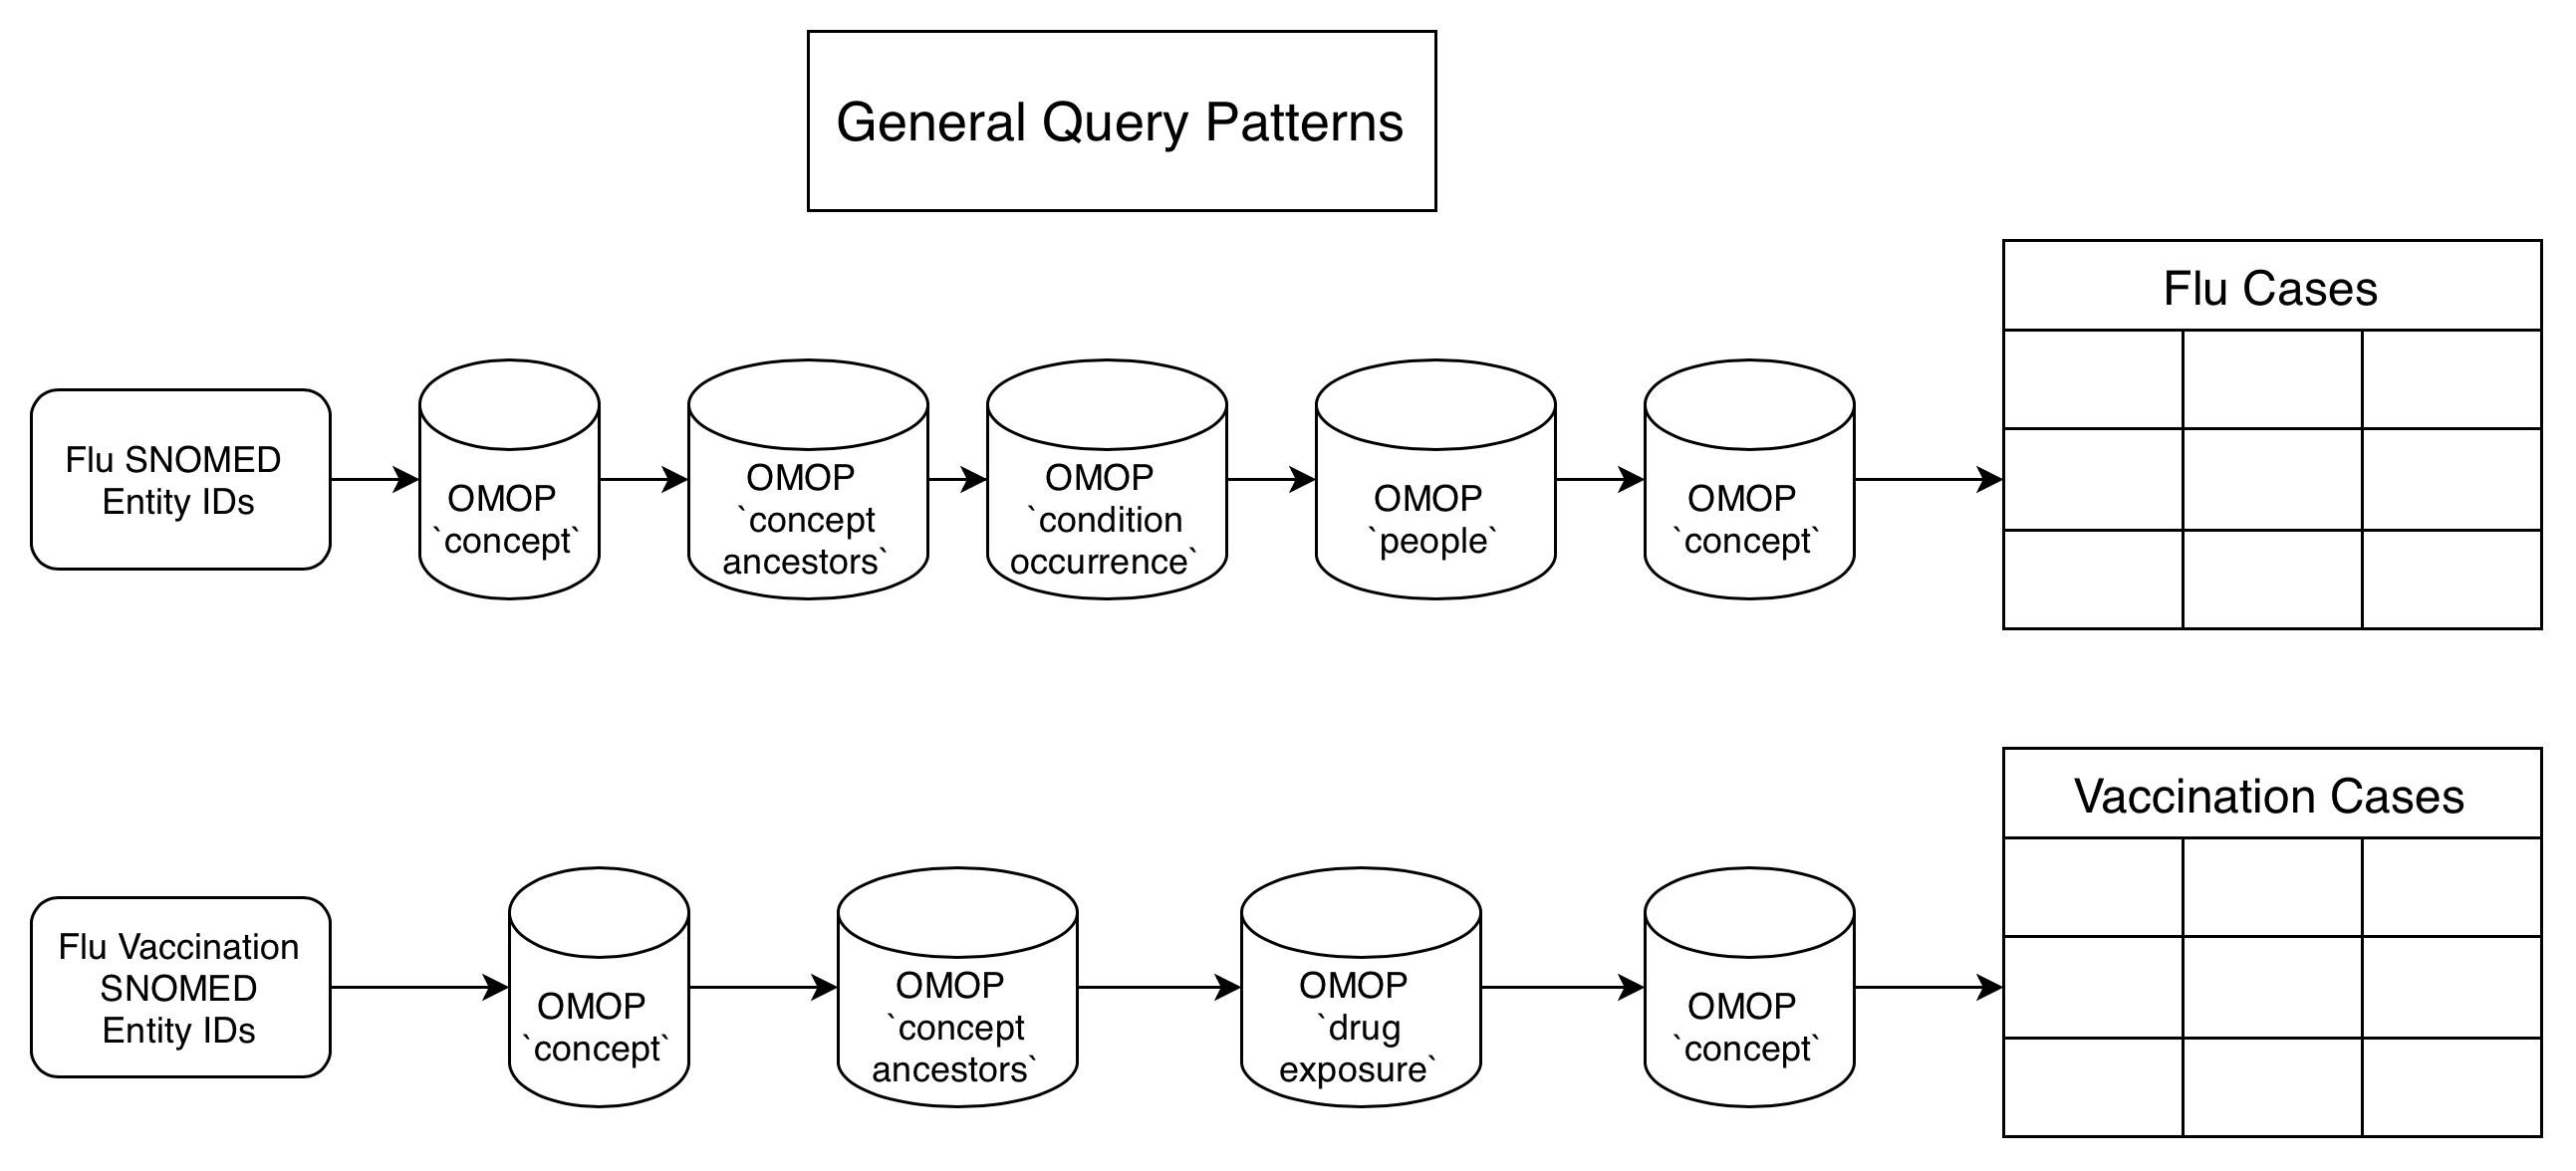

In [137]:
display(Markdown("### Example of Concept and Descendents in SNOMED Vocabulary"))
Image(filename='images/query_steps.png') 

In [138]:
flu_vaccine_df = get_drug_treatments(vaccine_concept_codes)

Number of cases: 1,708,934
Number of unique patients: 977,094



,drug_type_concept_id,stop_reason,refills,quantity,days_supply,sig,route_concept_id,lot_number,provider_id,visit_occurrence_id,...,dose_unit_source_value,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_date,drug_exposure_start_datetime,drug_exposure_end_date,drug_exposure_end_datetime,verbatim_end_date,vaccine_label
0,38000175,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,653,52055896,...,NaN,58821855,1085229,42742499,2010-05-26,NaT,2010-06-25,NaT,NaT,"Influenza virus vaccine, trivalent (IIV3), spl..."
1,38000175,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,36550,45032938,...,NaN,50872784,938664,40757097,2009-09-07,NaT,2009-10-07,NaT,NaT,"Influenza virus vaccine (IIV), pandemic formul..."
2,38000175,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,77608,27748327,...,NaN,31344981,578543,40757097,2010-12-24,NaT,2011-01-23,NaT,NaT,"Influenza virus vaccine (IIV), pandemic formul..."
3,38000175,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,197802,55247447,...,NaN,62418022,1151755,40757097,2010-08-04,NaT,2010-09-03,NaT,NaT,"Influenza virus vaccine (IIV), pandemic formul..."
4,38000175,NaN,<NA>,NaN,<NA>,NaN,<NA>,NaN,740658,29677918,...,NaN,33522696,618920,40757097,2009-10-24,NaT,2009-11-23,NaT,NaT,"Influenza virus vaccine (IIV), pandemic formul..."


In [ ]:
# flu_vaccine_df = flu_vaccine_df[['drug_type_concept_id', 'provider_id',
#                                 'visit_occurrence_id', 'drug_source_value',
#                                 'drug_source_concept_id', 'drug_exposure_id', 'person_id',
#                                 'drug_concept_id', 'drug_exposure_start_date', 'drug_exposure_end_date',
#                                 'vaccine_label'
#                                 ]]

# flu_vaccine_df

In [141]:
flu_vaccine_df = flu_vaccine_df.dropna(axis=1)

In [142]:
## calculate length of drug - exposure. Curious why not single day
flu_vaccine_df['vaccine_exposure_length'] = flu_vaccine_df['drug_exposure_end_date'] - flu_vaccine_df['drug_exposure_start_date']

flu_vaccine_df['vaccine_exposure_length_int'] = pd.to_timedelta(flu_vaccine_df['vaccine_exposure_length']).dt.days

flu_vaccine_df

,drug_type_concept_id,visit_occurrence_id,drug_source_value,drug_source_concept_id,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_date,drug_exposure_end_date,vaccine_label,vaccine_exposure_length,vaccine_exposure_length_int
0,38000175,52055896,90654,42742499,58821855,1085229,42742499,2010-05-26,2010-06-25,"Influenza virus vaccine, trivalent (IIV3), spl...",30 days,30
1,38000175,45032938,90668,40757097,50872784,938664,40757097,2009-09-07,2009-10-07,"Influenza virus vaccine (IIV), pandemic formul...",30 days,30
2,38000175,27748327,90668,40757097,31344981,578543,40757097,2010-12-24,2011-01-23,"Influenza virus vaccine (IIV), pandemic formul...",30 days,30
3,38000175,55247447,90668,40757097,62418022,1151755,40757097,2010-08-04,2010-09-03,"Influenza virus vaccine (IIV), pandemic formul...",30 days,30
4,38000175,29677918,90668,40757097,33522696,618920,40757097,2009-10-24,2009-11-23,"Influenza virus vaccine (IIV), pandemic formul...",30 days,30
...,...,...,...,...,...,...,...,...,...,...,...,...
1708929,38000175,99745025,90658,2213440,112637726,2079129,2213440,2010-07-27,2010-08-26,"Influenza virus vaccine, trivalent (IIV3), spl...",30 days,30
1708930,38000175,107874308,90658,2213440,121807122,2248476,2213440,2010-07-27,2010-08-26,"Influenza virus vaccine, trivalent (IIV3), spl...",30 days,30
1708931,38000175,19524083,90658,2213440,22047821,407076,2213440,2010-07-27,2010-08-26,"Influenza virus vaccine, trivalent (IIV3), spl...",30 days,30
1708932,38000175,11446961,90658,2213440,12931582,238594,2213440,2010-07-27,2010-08-26,"Influenza virus vaccine, trivalent (IIV3), spl...",30 days,30


Interestingly, some of the drug-exposures have an end date. I would assume that flu vaccines would have the same start and end date. Looking at the data, seems like it is always one month exposure.

In [144]:
pd.DataFrame(flu_vaccine_df['vaccine_label'].value_counts())

,count
vaccine_label,
"Influenza virus vaccine, trivalent (IIV3), split virus, 0.5 mL dosage, for intramuscular use",1542698
"Influenza virus vaccine, trivalent (IIV3), split virus, preservative free, 0.5 mL dosage, for intramuscular use",139389
"Influenza virus vaccine (IIV), split virus, preservative free, enhanced immunogenicity via increased antigen content, for intramuscular use",21841
"Influenza virus vaccine, trivalent (IIV3), split virus, 0.25 mL dosage, for intramuscular use",3064
"Influenza virus vaccine, trivalent, live (LAIV3), for intranasal use",1448
"Influenza virus vaccine, trivalent (IIV3), split virus, preservative free, 0.25 mL dosage, for intramuscular use",384
"Influenza virus vaccine, trivalent (ccIIV3), derived from cell cultures, subunit, preservative and antibiotic free, 0.5 mL dosage, for intramuscular use",59
"Influenza virus vaccine (IIV), pandemic formulation, split virus, preservative free, for intramuscular use",20
"Influenza virus vaccine (IIV), pandemic formulation, split virus, for intramuscular use",18


In [ ]:
# df = flu_vaccine_df.groupby('person_id')['vaccine_label'].apply(list)
# df

In [ ]:
# pd.DataFrame(flu_vaccine_df['vaccine_exposure_length_int'].value_counts())

In [ ]:
### 
flu_vaccine_df[flu_vaccine_df.duplicated(subset=['person_id', 'provider_id', 'drug_exposure_start_date'])]

In [ ]:
flu_vaccine_deduped = flu_vaccine_df.drop_duplicates(subset=['person_id', 'drug_exposure_start_date'])
flu_vaccine_deduped

In [ ]:
### people were vaccinated multiple times
times_vaccinated = pd.DataFrame(flu_vaccine_deduped['person_id'].value_counts()).reset_index()
times_vaccinated = times_vaccinated.rename(columns={'count': 'times_flu_vaccinated'})
times_vaccinated

In [ ]:
cardiac_df = get_total_cases(concept_codes_dict = cardiac_concept_codes)

# cardiac_df = cleanup_empty_columns(cardiac_df)

In [ ]:
cardiac_df['ancestor_concept_id'].value_counts()

In [ ]:
# same_date_dups = cardiac_df[cardiac_df.duplicated(subset=['person_id', 'condition_start_date'])].sort_values(by='person_id')
# same_date_dups

### Redundant Data

For a single patient, on a single visit, may be assigned:   
    * multiple disease disease codes for flu subtypes

For a single patient, during the same case of the flu:  
    * multiple visits, and therefore diagnoses may be recorded   
    * these can be difficult to detect, as there start dates may differ  
    * cases may overlap

condition_

In [ ]:
person_seven = cardiac_df[cardiac_df['person_id'] == 7].sort_values(by='condition_start_date')

person_seven[['person_id', 'descendant_concept_id', 'visit_occurrence_id', 
              'condition_occurrence_id', 'condition_start_date', 'condition_end_date', 
              'condition_label']]

In [ ]:
# person_seven = cardiac_df[cardiac_df['person_id'] == 7].sort_values(by='condition_start_date')
# person_seven

person_seven[['condition_era_id', 'condition_concept_id', 'condition_era_start_date']]

Deduplicate based on the person and date of diagnosis beginning and ending. 

In [ ]:
## by deduping, we lose details on the subtypes assigned - could pivot to track as subtypes list in columns
cardiac_df_deduped = cardiac_df.drop_duplicates(subset=['person_id', 'condition_start_date', 'condition_end_date'])
cardiac_df_deduped = cardiac_df_deduped.drop_duplicates(subset=['condition_era_id'])

In [ ]:
most_cases = cardiac_df_deduped[cardiac_df_deduped['person_id'] == 1137719].sort_values(by='condition_start_date')

display(most_cases['condition_concept_id'].value_counts())
display(most_cases['condition_occurrence_id'].value_counts())

most_cases.head()

In [ ]:
most_cases = most_cases.drop_duplicates(subset=['person_id', 'condition_start_date', 'condition_end_date'])
most_cases = most_cases.drop_duplicates(subset=['condition_era_id'])

most_cases = most_cases.sort_values(by='condition_era_start_date')
most_cases = most_cases.reset_index(drop=True).reset_index()

In [ ]:
most_cases

In [ ]:


# most_cases = most_cases.reset_index().sort_index()


start = pd.to_datetime(most_cases['condition_era_start_date'])
end = pd.to_datetime(most_cases['condition_era_end_date'].apply(lambda x: x + datetime.timedelta(days=1)))

most_cases['start'] = start
most_cases['end'] = end

px.timeline(most_cases, y = 'index', x_start='start', x_end = 'end', 
            title="Overlap of Cardiac Cases - Visit Date and Condition Era Deduplicated: Patient 1137719")

### How many cardiac events per each person after deduplicating same visits?

In [ ]:
num_cardiac_cases = pd.DataFrame(cardiac_df_deduped['person_id'].value_counts().value_counts().sort_index())
num_cardiac_cases = num_cardiac_cases.rename(columns={'count': 'num_patients'}).reset_index()
num_cardiac_cases = num_cardiac_cases.rename(columns={'count': 'num_cardiac_events'})

display(num_cardiac_cases)

In [ ]:
person_seven_clean = cardiac_df_deduped[cardiac_df_deduped['person_id'] == 7].sort_values(by='condition_start_date')
person_seven_clean

## Influenza Cases

In [ ]:
flu_df = get_total_cases(concept_codes_dict = flu_concept_codes)

flu_df = cleanup_empty_columns(flu_df)

In [ ]:
person_four_four_eight = flu_df[flu_df['person_id'] == 448]
## this has a duplicate as a result of a descent_id being linked to two ancestors
person_four_four_eight

In [ ]:
flu_df_deduped = flu_df.drop_duplicates(subset=['person_id', 
                                                'condition_start_date', 
                                                'condition_end_date'])

In [ ]:
flu_df.columns

In [ ]:
flu_df_deduped = flu_df_deduped.drop_duplicates(subset=['condition_era_id'])

In [ ]:
flu_counts = flu_df_deduped.value_counts('person_id').reset_index()
flu_counts = flu_counts.rename(columns={'count': 'flu_cases'})

if 'flu_cases' not in flu_df_deduped.columns:
  flu_df_deduped = flu_df_deduped.merge(flu_counts, how='outer', on = 'person_id')


assert (flu_df_deduped['flu_cases'] > 0).all(), 'Zero flu cases are found in the data'

In [ ]:
# cardiac_df_deduped

In [ ]:
cardiac_counts = cardiac_df_deduped.value_counts('person_id').reset_index()
cardiac_counts = cardiac_counts.rename(columns={'count': 'cardiac_cases'})

if 'cardiac_counts' not in cardiac_df_deduped.columns:
  cardiac_df_deduped = cardiac_df_deduped.merge(cardiac_counts, how='outer', on = 'person_id')


assert (cardiac_df_deduped['cardiac_cases'] > 0).all(), 'Zero cardiac cases are found in the data'

## Diagnosed with Flu and Cardiac Event

In [ ]:
case_joined = flu_df_deduped.merge(cardiac_df_deduped, how='inner', on='person_id', suffixes=('_flu', '_cardiac'))

print(f"""Number of people who have had cardiac problems and the flu: {len(case_joined['person_id'].unique()):,}\n""")
case_joined.head()

In [ ]:
def view_cross_conditions(df: pd.DataFrame, person_filter: int = None):


  if person_filter:
    df = df[df['person_id'] == person_filter]

  display(df[['person_id',
             'condition_start_date_flu', 'condition_end_date_flu', 'condition_label_flu', 'age_at_diagnosis_flu',
             'condition_start_date_cardiac', 'condition_end_date_cardiac', 'condition_label_cardiac', 'age_at_diagnosis_cardiac']])



In [ ]:
case_joined['flu_cardiac_time_delta'] = case_joined['condition_end_date_cardiac'] - case_joined['condition_end_date_flu']
case_joined['flu_cardiac_time_delta_int'] = pd.to_timedelta(case_joined['flu_cardiac_time_delta']).dt.days
case_joined

In [ ]:
flu_vaccine_deduped.merge(case_joined, how='inner', on='person_id')['person_id'].nunique()

In [ ]:
cardiac_vaccine_joined = cardiac_df_deduped.merge(flu_vaccine_deduped, how='outer', on='person_id')
cardiac_vaccine_joined['ever_vaccinated'] = np.where(cardiac_vaccine_joined['drug_exposure_start_date'].isnull(),
                                                    False,
                                                    True)

cardiac_vaccine_joined['vaccine_time_to_cardiac'] = cardiac_vaccine_joined['drug_exposure_start_date'] - cardiac_vaccine_joined['condition_start_date']
cardiac_vaccine_joined['cardiac_cases'] = cardiac_vaccine_joined['cardiac_cases'].fillna(0)

### outer joined - so not all individuals have cardiac problems and not all individuals have vaccines
### they have had at least one if not both
# cardiac_vaccine_joined = cardiac_vaccine_joined.merge()

In [ ]:
pd.DataFrame(cardiac_vaccine_joined.drop_duplicates(subset=['person_id'])['ever_vaccinated'].value_counts())

In [ ]:
## add the column counting number of vaccinations 
cardiac_vaccine_joined = cardiac_vaccine_joined.merge(times_vaccinated, how='left', on = 'person_id')
cardiac_vaccine_joined['times_flu_vaccinated'] = cardiac_vaccine_joined['times_flu_vaccinated'].fillna(0).astype(int)
cardiac_vaccine_joined['cardiac_cases'] = cardiac_vaccine_joined['cardiac_cases'].fillna(0).astype(int)

In [ ]:
cardiac_vaccine_people_deduped = cardiac_vaccine_joined[['person_id', 'cardiac_cases', 'times_flu_vaccinated']].drop_duplicates()

assert cardiac_vaccine_people_deduped['person_id'].nunique() == len(cardiac_vaccine_people_deduped), 'DF not deduplicated'
cardiac_vaccine_people_deduped

### Individuals that have had at least one cardiac event and one vaccination

In [ ]:
sns.boxplot(data=cardiac_vaccine_people_deduped, x='times_flu_vaccinated', y='cardiac_cases')
plt.title("Frequency of Cardiac Events given Number of Vaccinations")
plt.show()

In [ ]:
cardiac_vaccine_joined['vaccine_time_to_cardiac_int'] = pd.to_timedelta(cardiac_vaccine_joined['vaccine_time_to_cardiac']).dt.days

cardiac_after_vaccine = cardiac_vaccine_joined[cardiac_vaccine_joined['vaccine_time_to_cardiac_int'] >= 0]
# cardiac_after_vaccine = cardiac_after_vaccine.sort_values(by='vaccine_time_to_cardiac_int').drop_duplicates(subset=['person_id'])

In [ ]:
cardiac_after_vaccine['vaccine_time_to_cardiac_int'].hist(bins=100)
plt.title("Time to Cardiac Event after Flu Vaccination\n(Persons not Deduplicated)")
plt.xlabel("Days")
plt.show()

In [ ]:
view_cross_conditions(case_joined, 23742)

In [ ]:
closest_distance = case_joined[case_joined['flu_cardiac_time_delta_int'] >= 0]
closest_distance = closest_distance.sort_values(by=['flu_cardiac_time_delta_int']).drop_duplicates(subset='person_id')
closest_distance

In [ ]:
view_cross_conditions(closest_distance)

In [ ]:
case_joined[case_joined['person_id'] ==  2464]

In [ ]:
closest_distance['flu_cardiac_time_delta_int'].hist(bins=100)

plt.title("Shortest Time Between Flu and Cardiac Event")
plt.ylabel("Case Count")
plt.xlabel("Days Between Flu and Cardiac Event")
plt.show()

In [ ]:
case_joined.groupby(['flu_cases'])['cardiac_cases'].mean()

In [ ]:
sns.boxplot(data = case_joined[['flu_cases', 'cardiac_cases']],
            x = 'flu_cases',
            y='cardiac_cases')

plt.title("Number of Cardiac Events Related to Number of Flu Cases")
plt.show()

In [ ]:
plt.hist(flu_df_deduped['age_at_diagnosis'], density=True, histtype='step', label='Flu Cases')
plt.hist(cardiac_df_deduped['age_at_diagnosis'], density=True, histtype='step', label='Cardiac Cases')

## need to address the join complexity of this section and the ages when crossed
# plt.hist(case_joined['patient_age_cardiac'], density=True, histtype='step', label = 'Overlapping')

plt.title("Age (at Diagnosis) Distribution of Flu and Cardiac Cases")

plt.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots(2, 1, figsize = (11, 7), sharex=True)

df_dict = {'flu': flu_df_deduped,
          'cardiac': cardiac_df_deduped,
           }

i = 0
for name, df in df_dict.items():

  month_order = df['condition_start_date_month'].value_counts().sort_index().reset_index()

  ax[i].bar(month_order['condition_start_date_month'], month_order['count'])
  ax[i].set_xticks(np.arange(1, 13, 1))
  ax[i].set_label("Month")
  ax[i].set_ylabel(f"Number of {name.title()} Cases")
  ax[i].set_title(f"{name.title()} Cases per Month")

  i += 1

plt.show()

### For those that received the flu vaccine vs not
* What is the rate of getting the flu in the next 7 months
* What is the rate of having a cardiac event in the next seven months


** What is time zero to compare in a survival analysis if our comparison group did not receive a treatment?

* For those that had a heart attack vs not:
- how many had the flu in the past seven months 

### Conditional Probabilities

Irrespective of time or number of cases, how connected are flu diagnoses and cardiac problems?



In [ ]:
## get total number of people
query = """
        SELECT COUNT(DISTINCT(`person_id`)) as `num_total_people`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.person`
        ;"""

unique_people_df = CLIENT.query(query).to_dataframe()
display(unique_people_df)

unique_people = unique_people_df['num_total_people'].iloc[0]

In [ ]:
cardiac_df['person_id'].nunique()

In [ ]:
w_cardiac = cardiac_df['person_id'].nunique() / unique_people
w_flu = flu_df['person_id'].nunique() / unique_people
w_both = case_joined['person_id'].nunique() / unique_people
if_independent = w_cardiac * w_flu

print(f"Proportion of people with cardiac records: {np.round(w_cardiac, 3):,}")
print(f"Proportion of people with flu cases: {np.round(w_flu, 3):,}")


If we were to assume that the diagnosis of the flu and cardiac events are completely independent, we would expect that the number of people who have both cases to be the rate of each multiplied by each other

In [ ]:

print(f"""Assumming statistical independence, the ratio of people with both flu and cardiac events:""")
print(f"{np.round(if_independent, 4)}")
print("---")
print(f"The actual prevalence of individuals who have been diagnosed with both the flu and cardiac events")
print(f"{np.round(w_both, 4)}")

print(f"""
Ratio of actual vs expected: {np.round(w_both / if_independent, 3)}
""")

In a real life scenario, is this informative? Potentially, but too simplistic for any real insight.

### Survival Analysis - Difference in Time to Cardiac Event for Vaccinated vs Unvaccinated Individuals?

## Outer Joined - All Patients

In [ ]:
all_cases = flu_df.merge(cardiac_df,
                         how='outer',
                         on='person_id',
                         suffixes=('_flu', '_cardiac'))
all_cases